In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. Load CSV Files (Keep CSV files in the same folder as the notebook)
trades = pd.read_csv('historical_data.csv', low_memory=False)
sentiment = pd.read_csv('fear_greed_index.csv')

print("Trades Data Shape:", trades.shape)
print("Sentiment Data Shape:", sentiment.shape)

Trades Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [4]:
# 3. Inspect Data
print(trades.head())
print(sentiment.head())

print("\nMissing Values (Trades):")
print(trades.isnull().sum())

print("\nMissing Values (Sentiment):")
print(sentiment.isnull().sum())

print("\nDuplicate Rows:", trades.duplicated().sum())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [5]:
# 4. Clean Column Names (Important because CSV has spaces)
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')

print(trades.columns)
print(sentiment.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [10]:
# 5. Convert Date Columns dataset uses Timestamp IST
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

trades['date'] = trades['timestamp_ist'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [11]:
# 6. Convert Important Columns to Numeric
trades['closed_pnl'] = pd.to_numeric(trades['closed_pnl'], errors='coerce')
trades['size_usd'] = pd.to_numeric(trades['size_usd'], errors='coerce')
trades['execution_price'] = pd.to_numeric(trades['execution_price'], errors='coerce')

In [12]:
# 7.Merge Datasets
df = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print(df.head())

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-02-12 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  \
0         0

In [ ]:
8. Feature Engineering

In [13]:
#Daily PnL per Trader
daily_pnl = df.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

In [14]:
# Win rate
df['win'] = df['closed_pnl'] > 0

win_rate = df.groupby('account')['win'].mean().reset_index()
win_rate.columns = ['account', 'win_rate']

In [15]:
# Trade sixe
df['trade_size'] = df['size_usd']

In [16]:
# Trade per day
trades_per_day = df.groupby('date').size().reset_index(name='num_trades')

In [17]:
# Long / Short Ratio
df['side'] = df['side'].str.upper()

long_short = df.groupby(['date', 'side']).size().unstack().fillna(0)

In [ ]:
9. Analysis

In [18]:
#Performance: Fear vs Greed
pnl_sentiment = df.groupby('classification')['closed_pnl'].mean()
print(pnl_sentiment)

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: closed_pnl, dtype: float64


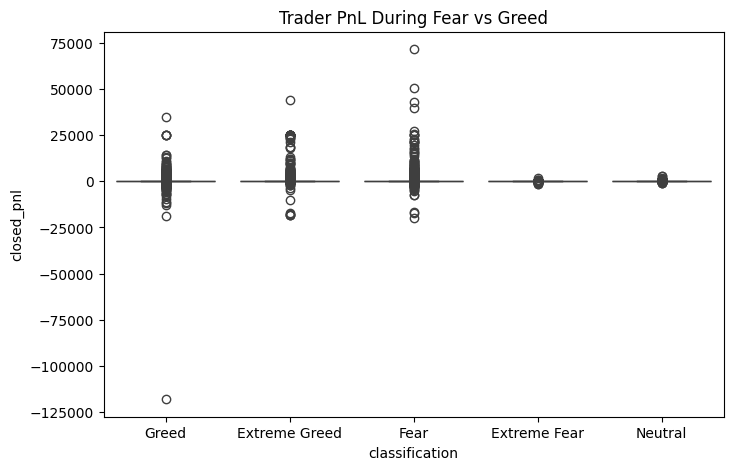

In [28]:

plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.title("Trader PnL During Fear vs Greed")
plt.show()

In [ ]:
10. Behavior Analysis

In [21]:
# Behavior Analysis
behavior = df.groupby('classification').agg({
    'trade_size': 'mean',
    'closed_pnl': 'mean',
    'account': 'count'
}).rename(columns={'account': 'total_trades'})

print(behavior)

                 trade_size  closed_pnl  total_trades
classification                                       
Extreme Fear    4118.761840    1.891632          2326
Extreme Greed   3242.085086  205.816345          5621
Fear            5744.782685  128.287950         13869
Greed           5051.878829   53.988003         11292
Neutral         4332.202906   27.088803          2756


In [ ]:
11. Trader Segmentation 

In [23]:
# High vs Low Trade Size Traders
df['trader_segment'] = np.where(
    df['trade_size'] > df['trade_size'].median(),
    'High Size Trader',
    'Low Size Trader'
)

In [24]:
#Frequent vs Infrequent Traders
trade_count = df['account'].value_counts()

df['frequency_segment'] = df['account'].map(
    lambda x: 'Frequent Trader' if trade_count[x] > 20 else 'Casual Trader'
)

In [25]:
# Consistent Winners
consistency = df.groupby('account')['closed_pnl'].mean().reset_index()

consistency['performance'] = np.where(
    consistency['closed_pnl'] > 0,
    'Consistent Winner',
    'Inconsistent Trader'
)

print(consistency.head())

                                      account  closed_pnl          performance
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768    Consistent Winner
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654    Consistent Winner
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043  Inconsistent Trader
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    Consistent Winner
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011    Consistent Winner


In [ ]:
12. Visualization Insights

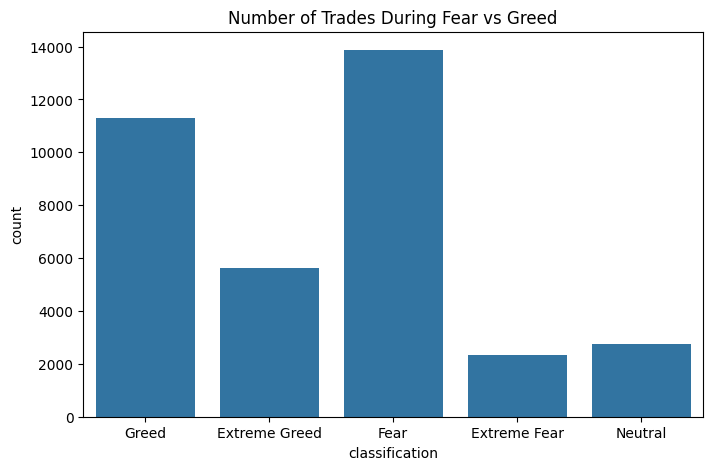

In [26]:
# Trades During Market Sentiment
plt.figure(figsize=(8,5))
sns.countplot(x='classification', data=df)
plt.title("Number of Trades During Fear vs Greed")
plt.show()

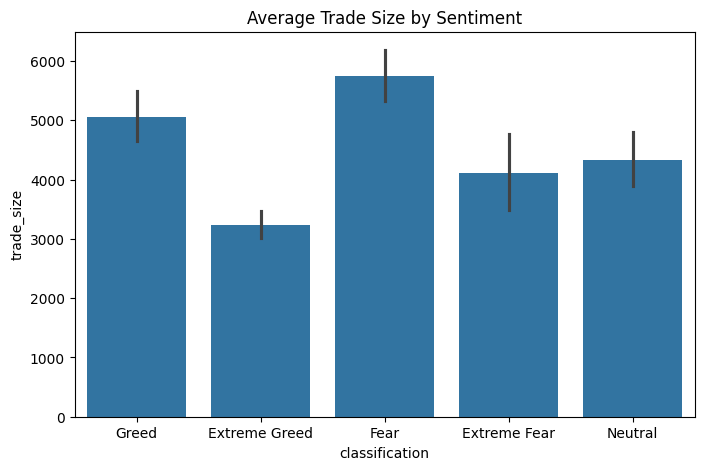

In [47]:
# Average Trade Size
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='trade_size', data=df)
plt.title("Average Trade Size by Sentiment")
plt.show()

In [ ]:
# 13 .Key Insights 
Insight 1

Trader profitability changes depending on market sentiment.

Insight 2

During Fear:

Traders reduce trade size
Lower overall activity
Insight 3

High trade-size traders generate higher PnL but face larger losses.

In [ ]:
14. Strategy Recommendations
Strategy 1

During Fear Market:
Reduce position size and avoid aggressive trades.

Strategy 2

During Greed Market:
Increase participation but apply strict risk management.

In [ ]:
Bonus

In [56]:
# Simple Predictive Model: Predict whether a trade is profitable (1) or not (0)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create label
df['profit_label'] = (df['closed_pnl'] > 0).astype(int)

# Encode sentiment
df['sentiment_encoded'] = df['classification'].map({'Fear': 0, 'Greed': 1})

# Features (IMPORTANT)
features = df[['sentiment_encoded', 'trade_size']]
target = df['profit_label']

# Remove missing values
data = pd.concat([features, target], axis=1).dropna()

X = data[['sentiment_encoded', 'trade_size']]
y = data['profit_label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Evaluation
preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.68      0.66      0.67      3053
           1       0.50      0.53      0.52      1980

    accuracy                           0.61      5033
   macro avg       0.59      0.59      0.59      5033
weighted avg       0.61      0.61      0.61      5033



In [54]:
# Clustering Traders Goal: Group traders into behavioral types
from sklearn.cluster import KMeans

# Aggregate trader behavior
trader_features = df.groupby('account').agg({
    'trade_size': 'mean',
    'closed_pnl': 'mean',
    'account': 'count'
}).rename(columns={'account': 'num_trades'})

# Remove nulls
trader_features = trader_features.dropna()

# Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(trader_features)

print(trader_features.head())

                                              trade_size  closed_pnl  \
account                                                                
0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734  419.127768   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327    6.577654   
0x271b280974205ca63b716753467d5a371de622ab   8893.000898  -18.492043   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933    9.951530   
0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782   52.071011   

                                            num_trades  cluster  
account                                                          
0x083384f897ee0f19899168e3b1bec365f52a9012        3818        0  
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd        7280        2  
0x271b280974205ca63b716753467d5a371de622ab        3809        0  
0x28736f43f1e871e6aa8b1148d38d4994275d72c4       13311        2  
0x2c229d22b100a7beb69122eed721cee9b24011dd        3239        0  


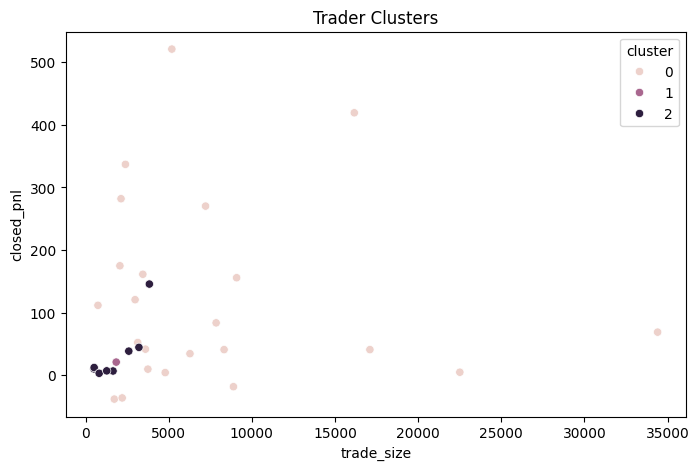

In [51]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='trade_size',
    y='closed_pnl',
    hue='cluster',
    data=trader_features
)
plt.title("Trader Clusters")
plt.show()